<a href="https://colab.research.google.com/github/aaa360hh-ndvi/NDVI-Carbon-Analysis./blob/main/json.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Course Title: Mobile App Development
Enrolled Students:
- Alice (Grade: A)
- Bob (Grade: B)
- Charlie (Grade: A+)

DataFrame of Students:
      name grade
0    Alice     A
1      Bob     B
2  Charlie    A+


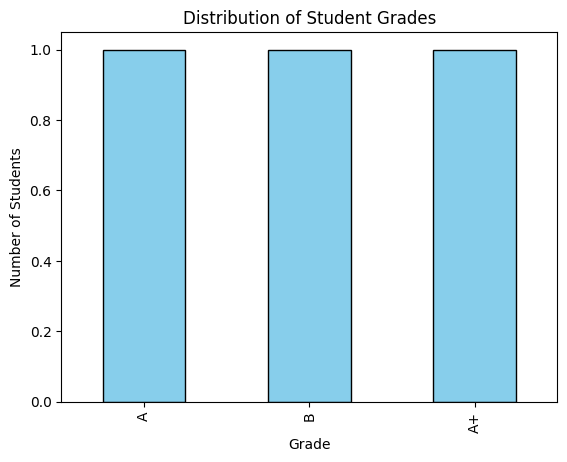

In [1]:
# Developed by Hussein - Mobile App Data Architecture Project.

import json
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Model Classes
# -------------------------------
class Student:
    def __init__(self, name: str, grade: str):
        self.name = name
        self.grade = grade

    @staticmethod
    def from_json(data: dict):
        return Student(name=data["name"], grade=data["grade"])

    def to_json(self) -> dict:
        return {"name": self.name, "grade": self.grade}


class Course:
    def __init__(self, title: str, course_id: int, students: list):
        self.title = title
        self.id = course_id
        self.students = students

    @staticmethod
    def from_json(data: dict):
        students = [Student.from_json(s) for s in data["students"]]
        return Course(title=data["title"], course_id=data["id"], students=students)

    def to_json(self) -> dict:
        return {
            "title": self.title,
            "id": self.id,
            "students": [s.to_json() for s in self.students],
        }


# -------------------------------
# Main Logic
# -------------------------------
def main():
    raw_json = """
    {
        "title": "Mobile App Development",
        "id": 501,
        "students": [
            {"name": "Alice", "grade": "A"},
            {"name": "Bob", "grade": "B"},
            {"name": "Charlie", "grade": "A+"}
        ]
    }
    """

    # Decode JSON string into Python dict
    decoded_json = json.loads(raw_json)

    # Convert dict into Course object
    course = Course.from_json(decoded_json)

    # Print course details
    print("Course Title:", course.title)
    print("Enrolled Students:")
    for student in course.students:
        print(f"- {student.name} (Grade: {student.grade})")

    # -------------------------------
    # Use pandas to display students in a DataFrame
    # -------------------------------
    df = pd.DataFrame([s.to_json() for s in course.students])
    print("\nDataFrame of Students:")
    print(df)

    # -------------------------------
    # Visualization: Count grades
    # -------------------------------
    grade_counts = df["grade"].value_counts()
    grade_counts.plot(kind="bar", color="skyblue", edgecolor="black")
    plt.title("Distribution of Student Grades")
    plt.xlabel("Grade")
    plt.ylabel("Number of Students")
    plt.show()


if __name__ == "__main__":
    main()
